# 📚 CodeAlpha — Web Scraping Project

**Task 1: Web Scraping**

This notebook demonstrates how to collect structured book data from the public **Books to Scrape** demo website using Python, Requests, BeautifulSoup, and Pandas.

The site explicitly describes itself as a sandbox for scraping practice. Prices and ratings on the site are randomly assigned and have no real-world meaning.


## Objective

- Identify a public website suitable for scraping.
- Extract book title, price, availability, rating, and product URL.
- Handle multiple catalogue pages.
- Clean the collected data.
- Save the result as a CSV dataset.


In [19]:
!pip install requests beautifulsoup4 pandas lxml



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from pathlib import Path
import time
from urllib.parse import urljoin
import requests
from bs4 import BeautifulSoup
import pandas as pd

BASE_URL = 'https://books.toscrape.com/catalogue/page-{}.html'
HEADERS = {'User-Agent': 'Mozilla/5.0 (CodeAlpha Web Scraping Project)'}


In [21]:
def scrape_page(url):
    response = requests.get(url, headers=HEADERS, timeout=20)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, 'html.parser')

    records = []

    for card in soup.select('article.product_pod'):

        title_tag = card.select_one('h3 a')
        price_tag = card.select_one('.price_color')
        availability_tag = card.select_one('.availability')
        rating_tag = card.select_one('p.star-rating')

        # Rating
        rating_map = {
            'One': 1,
            'Two': 2,
            'Three': 3,
            'Four': 4,
            'Five': 5
        }

        rating = next(
            (
                rating_map[x]
                for x in rating_map
                if x in rating_tag.get('class', [])
            ),
            None
        )

        # Price
        price_text = price_tag.get_text(strip=True)

        # Remove currency symbol and keep only the numeric value
        price_text = price_text.replace('£', '').replace('Â', '').strip()

        price = float(price_text)

        records.append({
            'title': title_tag.get('title', '').strip(),
            'price_gbp': price,
            'availability': availability_tag.get_text(' ', strip=True),
            'rating': rating,
            'product_url': urljoin(
                url,
                title_tag.get('href', '')
            )
        })

    return records

In [22]:
all_books = []

for page in range(1, 51):
    url = BASE_URL.format(page)
    try:
        page_books = scrape_page(url)
        if not page_books:
            break
        all_books.extend(page_books)
        print(f'Page {page}: {len(page_books)} books')
        time.sleep(0.4)
    except requests.RequestException as e:
        print('Stopped:', e)
        break

books = pd.DataFrame(all_books).drop_duplicates('title')
books.head()


Page 1: 20 books
Page 2: 20 books
Page 3: 20 books
Page 4: 20 books
Page 5: 20 books
Page 6: 20 books
Page 7: 20 books
Page 8: 20 books
Page 9: 20 books
Page 10: 20 books
Page 11: 20 books
Page 12: 20 books
Page 13: 20 books
Page 14: 20 books
Page 15: 20 books
Page 16: 20 books
Page 17: 20 books
Page 18: 20 books
Page 19: 20 books
Page 20: 20 books
Page 21: 20 books
Page 22: 20 books
Page 23: 20 books
Page 24: 20 books
Page 25: 20 books
Page 26: 20 books
Page 27: 20 books
Page 28: 20 books
Page 29: 20 books
Page 30: 20 books
Page 31: 20 books
Page 32: 20 books
Page 33: 20 books
Page 34: 20 books
Page 35: 20 books
Page 36: 20 books
Page 37: 20 books
Page 38: 20 books
Page 39: 20 books
Page 40: 20 books
Page 41: 20 books
Page 42: 20 books
Page 43: 20 books
Page 44: 20 books
Page 45: 20 books
Page 46: 20 books
Page 47: 20 books
Page 48: 20 books
Page 49: 20 books
Page 50: 20 books


,title,price_gbp,availability,rating,product_url
0,A Light in the Attic,51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,In stock,1,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a...


In [23]:
books.info()
books.describe(include='all')


<class 'pandas.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         999 non-null    str    
 1   price_gbp     999 non-null    float64
 2   availability  999 non-null    str    
 3   rating        999 non-null    int64  
 4   product_url   999 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 46.8 KB


,title,price_gbp,availability,rating,product_url
count,999,999.000000,999,999.000000,999
unique,999,NaN,1,NaN,999
top,A Light in the Attic,NaN,In stock,NaN,https://books.toscrape.com/catalogue/a-light-i...
freq,1,NaN,999,NaN,1
mean,NaN,35.073123,NaN,2.920921,NaN
std,NaN,14.453659,NaN,1.434178,NaN
min,NaN,10.000000,NaN,1.000000,NaN
25%,NaN,22.105000,NaN,2.000000,NaN
50%,NaN,36.000000,NaN,3.000000,NaN
75%,NaN,47.475000,NaN,4.000000,NaN


In [24]:
# Save the scraped dataset
Path('../data').mkdir(exist_ok=True)
books.to_csv('../data/books.csv', index=False)
print(f'Saved {len(books)} records.')


Saved 999 records.


In [25]:
books.head()

,title,price_gbp,availability,rating,product_url
0,A Light in the Attic,51.77,In stock,3,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,In stock,1,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,In stock,1,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,In stock,4,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,https://books.toscrape.com/catalogue/sapiens-a...


In [26]:
books.describe(include='all')

,title,price_gbp,availability,rating,product_url
count,999,999.000000,999,999.000000,999
unique,999,NaN,1,NaN,999
top,A Light in the Attic,NaN,In stock,NaN,https://books.toscrape.com/catalogue/a-light-i...
freq,1,NaN,999,NaN,1
mean,NaN,35.073123,NaN,2.920921,NaN
std,NaN,14.453659,NaN,1.434178,NaN
min,NaN,10.000000,NaN,1.000000,NaN
25%,NaN,22.105000,NaN,2.000000,NaN
50%,NaN,36.000000,NaN,3.000000,NaN
75%,NaN,47.475000,NaN,4.000000,NaN


In [27]:
print("Missing values:")
print(books.isnull().sum())

print("\nDuplicate rows:")
print(books.duplicated().sum())

Missing values:
title           0
price_gbp       0
availability    0
rating          0
product_url     0
dtype: int64

Duplicate rows:
0


In [28]:
books.dtypes

title               str
price_gbp       float64
availability        str
rating            int64
product_url         str
dtype: object

In [29]:
books['title'] = books['title'].str.strip()
books['availability'] = books['availability'].str.strip()

books['price_gbp'] = pd.to_numeric(
    books['price_gbp'],
    errors='coerce'
)

books['rating'] = pd.to_numeric(
    books['rating'],
    errors='coerce'
)

books = books.drop_duplicates()

In [30]:
books.isnull().sum()

title           0
price_gbp       0
availability    0
rating          0
product_url     0
dtype: int64

In [31]:
books.to_csv('../data/books.csv', index=False)

print("Dataset saved successfully!")
print(f"Total books scraped: {len(books)}")

Dataset saved successfully!
Total books scraped: 999


In [32]:
books.head()
books.shape
books.info()
books.describe(include='all')

<class 'pandas.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         999 non-null    str    
 1   price_gbp     999 non-null    float64
 2   availability  999 non-null    str    
 3   rating        999 non-null    int64  
 4   product_url   999 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 46.8 KB


,title,price_gbp,availability,rating,product_url
count,999,999.000000,999,999.000000,999
unique,999,NaN,1,NaN,999
top,A Light in the Attic,NaN,In stock,NaN,https://books.toscrape.com/catalogue/a-light-i...
freq,1,NaN,999,NaN,1
mean,NaN,35.073123,NaN,2.920921,NaN
std,NaN,14.453659,NaN,1.434178,NaN
min,NaN,10.000000,NaN,1.000000,NaN
25%,NaN,22.105000,NaN,2.000000,NaN
50%,NaN,36.000000,NaN,3.000000,NaN
75%,NaN,47.475000,NaN,4.000000,NaN


In [33]:
books.to_csv('../data/books.csv', index=False)

In [34]:
books.isnull().sum()

title           0
price_gbp       0
availability    0
rating          0
product_url     0
dtype: int64

In [35]:
books.duplicated().sum()

np.int64(0)

In [36]:
print("Average Price:", books['price_gbp'].mean())
print("Maximum Price:", books['price_gbp'].max())
print("Minimum Price:", books['price_gbp'].min())

print("\nRating Distribution:")
print(books['rating'].value_counts().sort_index())

Average Price: 35.073123123123125
Maximum Price: 59.99
Minimum Price: 10.0

Rating Distribution:
rating
1    226
2    196
3    203
4    179
5    195
Name: count, dtype: int64


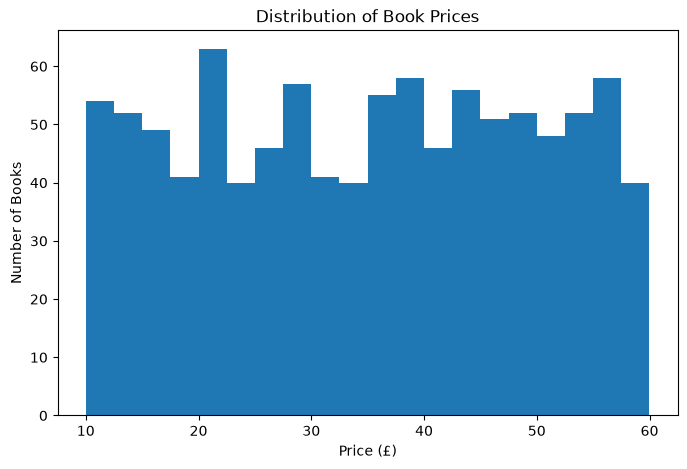

In [37]:
import matplotlib.pyplot as plt

# Price distribution
plt.figure(figsize=(8,5))
plt.hist(books['price_gbp'], bins=20)
plt.title('Distribution of Book Prices')
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.show()

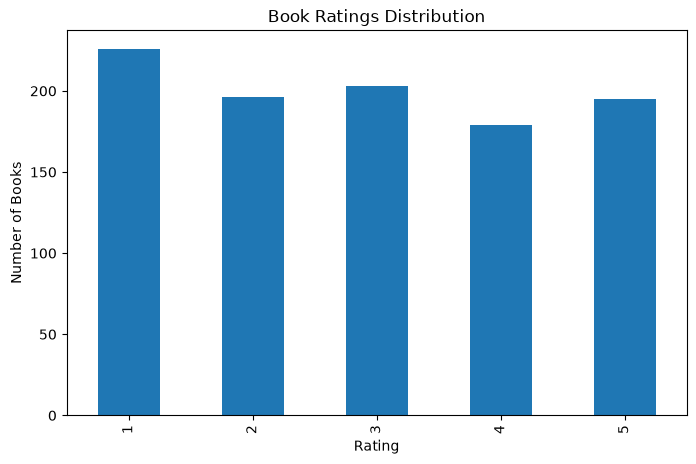

In [38]:
# Rating distribution
plt.figure(figsize=(8,5))
books['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Book Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Books')
plt.show()

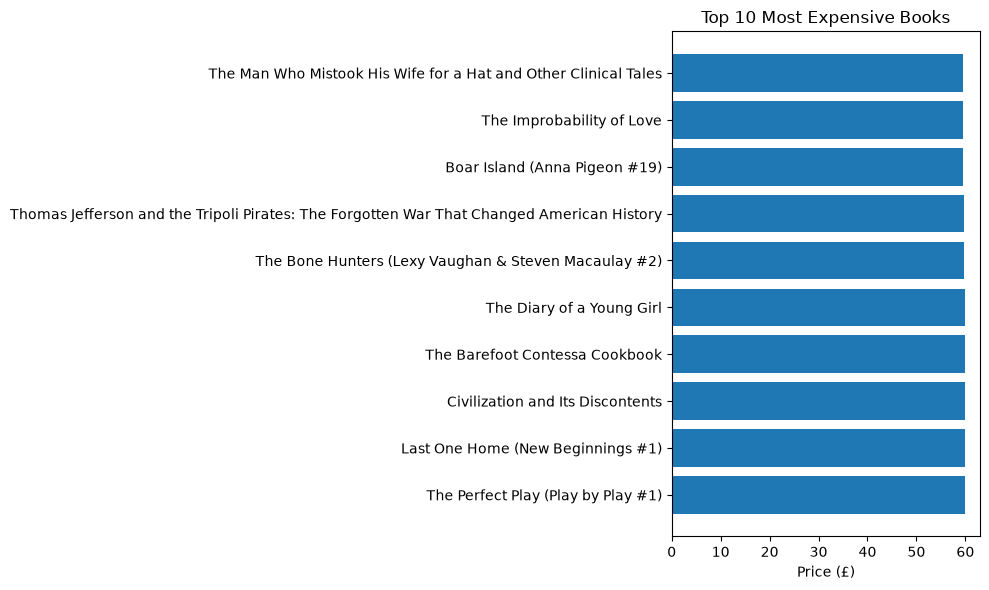

In [39]:
# Top 10 most expensive books
top10 = books.nlargest(10, 'price_gbp')

plt.figure(figsize=(10,6))
plt.barh(top10['title'], top10['price_gbp'])
plt.title('Top 10 Most Expensive Books')
plt.xlabel('Price (£)')
plt.tight_layout()
plt.show()

## Conclusion

The web scraping project successfully collected information for 999 books from Books to Scrape.

The dataset contains book titles, prices, availability, ratings, and product URLs. The analysis provides an overview of book pricing and rating patterns and demonstrates how web data can be collected, cleaned, structured, and analyzed using Python.

This project helped strengthen my understanding of Requests, BeautifulSoup, Pandas, data cleaning, and basic data visualization.

## Key Outcome

The scraper converts semi-structured HTML product cards into a clean tabular dataset that can be reused for EDA and visualization in later tasks.
